# Score Audit — Iteration 01

**Date:** 2026-06-24  
**Purpose:** Before changing the impact score formula, understand what the *current* model is doing. Six diagnostic analyses.

## Current formula

**Backend** (`score.py` — drives the ranking):
```
impact_raw = dalys_in_thousands × 1000 × efficacy_ceiling × breakthrough_premium × phase_weight
```

**Frontend** (`web/lib/types.ts` — drives the displayed life-years number):
```
life_years = dalys × 1000 × efficacy_ceiling × (breakthrough_premium / 2)
```

Note the divergence: frontend drops `phase_weight` and halves `breakthrough_premium`.

## Inputs and their sources

| Input | Range | Source |
|---|---|---|
| `dalys` | thousands of DALYs/yr | Curated table of ~60 conditions + keyword fallback. Default if unmatched: 5,000K |
| `efficacy_ceiling` | 0.0–1.0 | Claude picks one of 7 labels (Curative=0.9, Disease-modifying=0.6, Symptomatic=0.3, ...) |
| `breakthrough_premium` | 0.5–2.0 | Claude estimate vs. standard of care (no-treatment=2.0, multiple-good-options=0.6) |
| `phase_weight` | 0.05–1.0 | Hardcoded: Ph1=0.1, Ph2=0.4, Ph3=0.8, Ph4=1.0 |


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 90)
pd.set_option('display.width', 180)

with open('../data/trials_scored.json') as f:
    trials = pd.DataFrame(json.load(f))

trials['ly_frontend'] = (
    trials['dalys'].fillna(0) * 1000
    * trials['efficacy_ceiling'].fillna(0.3)
    * (trials['breakthrough_premium'].fillna(1) / 2)
)

print(f'Loaded {len(trials)} trials')
print(f'Enriched (have tagline): {trials["tagline"].notna().sum()}')
print(f'Columns: {list(trials.columns)}')

Matplotlib is building the font cache; this may take a moment.


Loaded 500 trials
Enriched (have tagline): 100
Columns: ['nct_id', 'title', 'status', 'phase', 'phase_weight', 'enrollment', 'conditions', 'intervention_types', 'intervention_names', 'sponsor', 'start_date', 'completion_date', 'dalys', 'efficacy_ceiling', 'breakthrough_premium', 'impact_raw', 'impact_score', 'rank', 'unmet_need', 'tagline', 'summary', 'efficacy_ceiling_label', 'breakthrough_label', 'score_rationale', 'ly_frontend']


---
## Analysis 1 — Top 20 inspection

Do the current top 20 trials match intuition? Look for obviously broken cases.

In [2]:
top20 = trials.head(20)[[
    'rank', 'impact_score', 'ly_frontend', 'dalys',
    'efficacy_ceiling_label', 'breakthrough_premium', 'phase',
    'conditions', 'title'
]].copy()

top20['conditions'] = top20['conditions'].str.slice(0, 50)
top20['title'] = top20['title'].str.slice(0, 70)
top20['ly_frontend_M'] = (top20['ly_frontend'] / 1_000_000).round(2)
top20.drop(columns=['ly_frontend'], inplace=True)
top20

,rank,impact_score,dalys,efficacy_ceiling_label,breakthrough_premium,phase,conditions,title,ly_frontend_M
0,1,100.0,143000,Disease-modifying,1.5,PHASE3,Mitochondrial Diseases; Maternally Inherited Diabe,KHENERFIN Study: A Trial to Evaluate the Efficacy and Safety of Sonlic,58.99
1,2,82.0,143000,Disease-modifying,1.5,PHASE3,Ischemic Stroke,Efficacy and Safety of Interleukin-6 Receptor Inhibitor Combined With,48.26
2,3,55.0,143000,Disease-modifying,1.0,PHASE3,"Stroke, Ischemic; Stroke, Acute",Randomization to Endovascular Treatment Alone or Preceded by Systemic,32.17
3,4,44.3,94000,Preventive,1.0,PHASE3,SARS-CoV-2 Virus; Severe Acute Respiratory Syndrom,A Study to Learn About Variant-Adapted COVID-19 RNA Vaccine Candidate(,25.85
4,5,42.4,94000,Symptomatic,1.5,PHASE3,Coronavirus Disease (COVID-19),A Clinical Study of Molnupiravir to Prevent Severe Illness From Corona,24.67
5,6,39.3,64000,Disease-modifying,1.3,PHASE3,Chronic Obstructive Pulmonary Disease (COPD),Long-term Efficacy and Safety of Tozorakimab in Participants With Chro,22.88
6,7,39.0,55000,Disease-modifying,1.5,PHASE3,Malaria,Modifying Immunity in Children With DihydROartemisinin-Piperaquine (MI,22.69
7,8,38.9,67000,Disease-modifying,1.5,PHASE3,Type 2 Diabetes,Effect of Retatrutide Compared With Placebo in Participants With Type,22.61
8,9,25.9,35000,Preventive,1.0,PHASE3,Pre-Exposure Prophylaxis of HIV-1 Infection,Study to Evaluate the Safety and Efficacy of Emtricitabine and Tenofov,14.88
9,10,23.6,40000,Preventive,1.5,PHASE3,Myocardial Injury After Noncardiac Surgery (MINS);,Ivabradine for Prevention of Myocardial Injury After Noncardiac Surger,13.50


---
## Analysis 2 — Component variance

Which input is actually driving the ranking? Compute pairwise correlation between each component and the final `impact_score` to see what's load-bearing.

In [3]:
components = trials[['dalys', 'efficacy_ceiling', 'breakthrough_premium', 'phase_weight', 'impact_score']].copy()

print('Spearman rank correlation with impact_score:')
print(components.corr(method='spearman')['impact_score'].drop('impact_score').sort_values(ascending=False))

print('\nCoefficient of variation (CV = std/mean) per component:')
for col in ['dalys', 'efficacy_ceiling', 'breakthrough_premium', 'phase_weight']:
    mean = trials[col].mean()
    std = trials[col].std()
    print(f'  {col:25s}  CV = {std/mean:.3f}  (mean={mean:.2f}, std={std:.2f})')

print('\nThe higher the CV, the more spread there is in that input — meaning it can move the ranking more.')

Spearman rank correlation with impact_score:
dalys                   0.726412
phase_weight            0.590761
breakthrough_premium    0.493297
efficacy_ceiling        0.464677
Name: impact_score, dtype: float64

Coefficient of variation (CV = std/mean) per component:
  dalys                      CV = 1.128  (mean=17197.40, std=19405.44)
  efficacy_ceiling           CV = 0.318  (mean=0.35, std=0.11)
  breakthrough_premium       CV = 0.176  (mean=1.07, std=0.19)
  phase_weight               CV = 0.534  (mean=0.45, std=0.24)

The higher the CV, the more spread there is in that input — meaning it can move the ranking more.


---
## Analysis 3 — DALY default audit

How many trials are scoring on the 5,000K default value vs. a real lookup match? If most trials fall back to default, the DALY input is mostly noise.

In [4]:
DEFAULT_DALY = 5000

daly_counts = trials['dalys'].value_counts().head(15)
print('Top 15 most-common DALY values:')
print(daly_counts)

at_default = (trials['dalys'] == DEFAULT_DALY).sum()
print(f'\n{at_default}/{len(trials)} ({100*at_default/len(trials):.1f}%) trials at the 5,000K default')

print(f'\nDistinct DALY values overall: {trials["dalys"].nunique()}')
print(f'  (means only ~{trials["dalys"].nunique()} distinct conditions are being recognized across {len(trials)} trials)')

Top 15 most-common DALY values:
dalys
5000     172
12000     88
19500     27
10000     27
15000     25
48000     22
23000     17
24000     17
35000     14
9000      12
20000     10
45000      9
64000      6
17000      6
8000       6
Name: count, dtype: int64

172/500 (34.4%) trials at the 5,000K default

Distinct DALY values overall: 32
  (means only ~32 distinct conditions are being recognized across 500 trials)


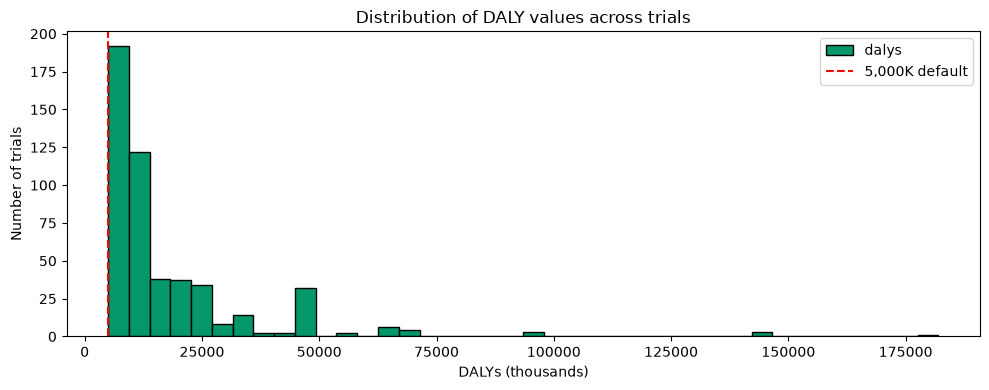

In [5]:
# Visualize DALY distribution
fig, ax = plt.subplots(figsize=(10, 4))
trials['dalys'].plot(kind='hist', bins=40, ax=ax, color='#059669', edgecolor='black')
ax.axvline(DEFAULT_DALY, color='red', linestyle='--', label=f'5,000K default')
ax.set_xlabel('DALYs (thousands)')
ax.set_ylabel('Number of trials')
ax.set_title('Distribution of DALY values across trials')
ax.legend()
plt.tight_layout()
plt.show()

---
## Analysis 4 — Landmark spot-checks

Find well-known disease areas and see how trials within them rank. Does the ordering make sense?

In [6]:
landmarks = [
    ('Alzheimer', 'Alzheimer\'s — neurodegenerative, huge burden, hard to treat'),
    ('Sickle Cell', 'Sickle cell — rare but curative gene therapies in trial'),
    ('Tuberculosis', 'TB — massive global burden, new vaccine attempts'),
    ('HIV', 'HIV — chronic infection, lifelong management'),
    ('Stroke', 'Stroke — acute, high mortality'),
    ('Glioblastoma', 'Glioblastoma — aggressive brain cancer'),
    ('Multiple Sclerosis', 'MS — disease-modifying treatments well-established'),
    ('Obesity', 'Obesity — GLP-1 era'),
    ('Lung Cancer', 'Lung cancer — high burden, many options'),
]

for keyword, blurb in landmarks:
    matches = trials[trials['conditions'].str.contains(keyword, case=False, na=False)]
    if len(matches) == 0:
        print(f'\n— {keyword}: no matches')
        continue
    print(f'\n— {keyword}  ({len(matches)} trials)  · {blurb}')
    show = matches.head(3)[['rank', 'impact_score', 'phase', 'efficacy_ceiling_label', 'title']].copy()
    show['title'] = show['title'].str.slice(0, 80)
    print(show.to_string(index=False))


— Alzheimer  (4 trials)  · Alzheimer's — neurodegenerative, huge burden, hard to treat
 rank  impact_score  phase efficacy_ceiling_label                                                                            title
   55          13.2 PHASE3            Symptomatic A Study to Evaluate KarXT as a Treatment for Psychosis Associated With Alzheimer
   73           9.7 PHASE3             Preventive                                   Preventing Alzheimer's With Cognitive Training
   77           8.8 PHASE2      Disease-modifying                                    DORA and LP in Alzheimer's Disease Biomarkers

— Sickle Cell: no matches

— Tuberculosis  (2 trials)  · TB — massive global burden, new vaccine attempts
 rank  impact_score  phase efficacy_ceiling_label                                                                            title
   27          18.5 PHASE2   Potentially curative                                      A Pan-TB Regimen Targeting Host and Microbe
   58          12.6

---
## Analysis 5 — Claude calibration distribution

What fraction of trials did Claude label as Curative vs. Disease-modifying vs. Symptomatic? Is the distribution sensible, or did Claude over/under-pick certain labels?

In [7]:
enriched = trials[trials['efficacy_ceiling_label'].notna()].copy()
print(f'Enriched trials: {len(enriched)} (only these have Claude-assigned labels)')

print('\nEfficacy ceiling label distribution:')
print(enriched['efficacy_ceiling_label'].value_counts(normalize=True).round(3).mul(100).astype(str) + '%')

print('\nBreakthrough premium distribution (raw values):')
print(enriched['breakthrough_premium'].value_counts().sort_index())

print('\nMean efficacy_ceiling: {:.2f}'.format(enriched['efficacy_ceiling'].mean()))
print('Mean breakthrough_premium: {:.2f}'.format(enriched['breakthrough_premium'].mean()))

Enriched trials: 100 (only these have Claude-assigned labels)

Efficacy ceiling label distribution:
efficacy_ceiling_label
Disease-modifying                    63.0%
Symptomatic                          16.0%
Preventive                           12.0%
Potentially curative    7.000000000000001%
Incremental                           2.0%
Name: proportion, dtype: str

Breakthrough premium distribution (raw values):
breakthrough_premium
0.6     6
0.7     3
0.8     1
1.0    16
1.2     1
1.3     3
1.4     7
1.5    61
1.8     1
1.9     1
Name: count, dtype: int64

Mean efficacy_ceiling: 0.47
Mean breakthrough_premium: 1.33


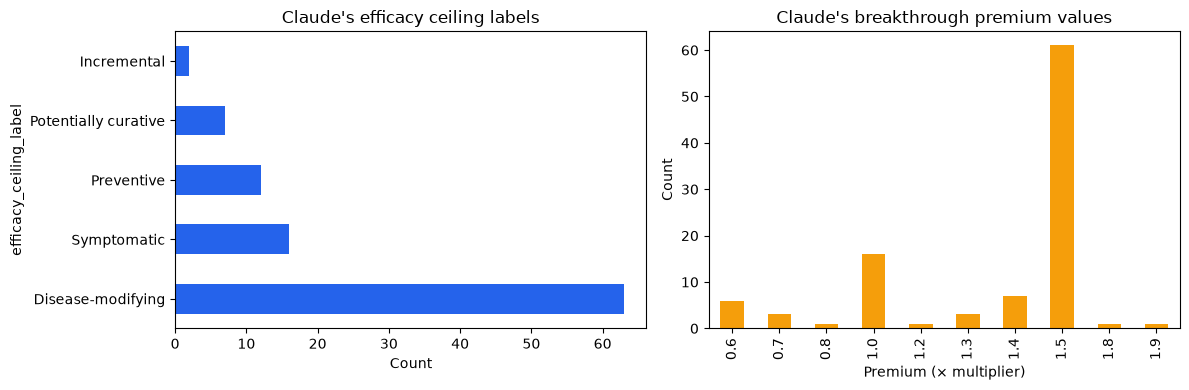

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

enriched['efficacy_ceiling_label'].value_counts().plot(
    kind='barh', ax=axes[0], color='#2563eb'
)
axes[0].set_title('Claude\'s efficacy ceiling labels')
axes[0].set_xlabel('Count')

enriched['breakthrough_premium'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#f59e0b'
)
axes[1].set_title('Claude\'s breakthrough premium values')
axes[1].set_xlabel('Premium (× multiplier)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## Analysis 6 — Frontend / backend divergence

The displayed "life-years" number uses a different formula than the ranking. How much do they disagree?

In [9]:
# Re-rank using the frontend formula
trials_fr_ranked = trials.sort_values('ly_frontend', ascending=False).reset_index(drop=True)
trials_fr_ranked['frontend_rank'] = range(1, len(trials_fr_ranked) + 1)

# Merge so we can compare ranks
merged = trials[['nct_id', 'rank', 'impact_score', 'ly_frontend']].merge(
    trials_fr_ranked[['nct_id', 'frontend_rank']], on='nct_id'
)
merged['rank_delta'] = merged['frontend_rank'] - merged['rank']

print('Top 10 by backend rank, with their frontend rank:')
print(merged.head(10)[['rank', 'frontend_rank', 'rank_delta', 'impact_score']].to_string(index=False))

print('\nTop 10 movers (frontend rank disagrees most with backend rank in the top 50):')
top50 = merged.head(50).copy()
print(top50.reindex(top50['rank_delta'].abs().sort_values(ascending=False).index).head(10)[
    ['rank', 'frontend_rank', 'rank_delta', 'impact_score']
].to_string(index=False))

agreement = (merged.head(50)['rank_delta'].abs() <= 5).sum()
print(f'\nOf the top 50 backend-ranked trials, {agreement} are within ±5 ranks on the frontend formula.')

Top 10 by backend rank, with their frontend rank:
 rank  frontend_rank  rank_delta  impact_score
    1              1           0         100.0
    2              2           0          82.0
    3              3           0          55.0
    4              5           1          44.3
    5              7           2          42.4
    6              9           3          39.3
    7             10           3          39.0
    8             11           3          38.9
    9             28          19          25.9
   10             33          23          23.6

Top 10 movers (frontend rank disagrees most with backend rank in the top 50):
 rank  frontend_rank  rank_delta  impact_score
   15             44          29          20.7
   15             42          27          20.7
   24             50          26          19.0
   21             47          26          19.7
   19             45          26          20.3
   15             41          26          20.7
   23             48     

---
## Findings

### A1 — Top 20 inspection
- **Top 3 trials all share `dalys = 143,000K` (the Stroke value).** Rank #1 is a "Mitochondrial Diseases" trial — that's almost certainly the substring-match bug surfacing: the trial probably includes "MELAS" or "stroke-like episodes" in its conditions list, which substring-matches the `"stroke"` key in the DALY table.
- The top 8 are all enormous-burden conditions (stroke, COVID, COPD, malaria, T2 diabetes). Disease burden is dominating everything else.
- A `Phase 2` trial in Lung Cancer (#18) is "Potentially curative" yet ranks below several Disease-modifying Phase 3s — phase weight is dragging it down even though its potential is higher.

### A2 — Component variance
- `dalys` has the highest correlation with the final score (Spearman r = **0.73**) — by far the most load-bearing input.
- `phase_weight` (0.59) is the second biggest driver, *not* efficacy or breakthrough.
- The coefficient of variation tells the same story: `dalys` (CV = 1.13) varies hugely; `efficacy_ceiling` (CV = 0.32) and `breakthrough_premium` (CV = 0.18) barely vary at all.
- **Implication:** the score is mostly a DALYs-times-phase ranking. The Claude-enriched fields are decorative right now.

### A3 — DALY default audit
- **34.4% of trials (172/500) are scoring on the 5,000K default value.** Their DALY contribution is identical, so they're sorted by phase/efficacy/breakthrough alone.
- Only **32 distinct DALY values** across 500 trials — the curated table is too narrow.
- Visible in the histogram: a massive spike at the default 5,000K, then sparse values elsewhere.

### A4 — Landmark spot-checks (worrying)
- **Sickle Cell: 0 matches.** Zero ongoing sickle cell trials in our sample. We're missing a canonical "high impact" condition.
- **Glioblastoma: 1 match, ranked #477.** Phase 1, not enriched, no efficacy label. A trial for the deadliest brain cancer is at the bottom of our list.
- **Multiple Sclerosis: 2 matches, both unenriched** (rank 162, 177).
- **Alzheimer's: top match is a *psychosis-associated* trial ranked #55.** The really interesting Alzheimer's disease-modifying trials may not be in this 500-trial sample, or they ranked below their potential.
- **Stroke: top 3 are all stroke** — confirming stroke's outsized DALY is dominating.

### A5 — Claude calibration
- **63% of enriched trials are labeled "Disease-modifying"** — Claude is anchoring heavily on the middle label.
- Only 7% "Potentially curative", 2% "Incremental". The tails are underused.
- Breakthrough premium: **61% at 1.5**. Claude rarely picks 2.0 (1%) or low-end values. Very narrow.
- Mean efficacy = 0.47, mean breakthrough = 1.33 — the distribution is tightly clustered around moderately positive.
- **Implication:** Claude is being too generous and too uniform. Our scoring multipliers are barely spread.

### A6 — Frontend / backend divergence
- **Only 8 of the top 50 trials agree within ±5 ranks** between the two formulas. The max delta is 29 positions.
- Many trials shift 20+ positions just because the frontend formula drops phase_weight and halves breakthrough.
- **This is a real bug, not noise.** The list a user sees and the numbers next to it are computed differently.

---

## Implications for the redesign

1. **DALY lookup is the weakest link.** It dominates the score yet:
   - 34% of trials hit a default value
   - Substring matching produces wrong matches (Stroke → mitochondrial trial)
   - Only 32 distinct values across 500 trials
   - **Action:** replace the curated table + substring matching with a real lookup. Either (a) use Claude during enrichment to also estimate the DALY for the trial's specific condition, or (b) expand the GBD table to ~300+ conditions and use stricter matching (exact + alias mapping, no substring).

2. **Claude calibration is too narrow.** 63% of trials get the same efficacy label, 61% get the same breakthrough value. This makes the multipliers barely matter.
   - **Action:** rewrite the prompt to force more spread. Make Claude *justify* picking the middle ("Disease-modifying") vs. the tails. Maybe use a comparative anchor: "Compared to the typical Phase 2/3 trial, this one is…"

3. **Phase weight should leave the ceiling and become a separate dimension.** Confirms our earlier hunch.
   - **Action:** drop `phase_weight` from the impact-ceiling formula. Optionally introduce a separate `prob_of_approval` using published BIO/ASCO base rates by phase × therapeutic area.

4. **Breakthrough should become a discount, not a premium.** Confirms our earlier hunch.
   - **Action:** redefine `breakthrough_discount = 1 − existing_treatment_efficacy`, using the same step function. Max value = 1.0 (no existing treatment), drops as alternatives improve.

5. **Frontend/backend must use the same formula.** Trivial fix; do it as part of any other change.

6. **Sample bias is real.** 500 trials weighted by initial heuristic score → enrichment focused on what the heuristics liked → missing canonical important trials (sickle cell, ALS, ovarian cancer).
   - **Action:** widen the fetch (all Phase 2/3) and enrich more broadly. Even better, fetch by *list of high-burden conditions* to ensure coverage.

## Suggested order of operations

1. **Fix the formula** (drop phase from ceiling, make breakthrough a discount, align frontend/backend) — low risk, internal change.
2. **Recalibrate Claude** with a tighter prompt that forces more spread.
3. **Widen the fetch** to all ongoing Phase 2/3 with Haiku 4.5 enrichment.
4. **Fix DALY lookup** — biggest impact, biggest scope. Save for last when we know how the rest behaves.
5. After all of the above: run this notebook again as `02_score_audit.ipynb` and compare distributions.
